<a href="https://colab.research.google.com/github/k2herat/DL2/blob/hw2/almetov_hw2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Исследование архитектуры DEER

In [ ]:
!pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=282066e7b5f4f23e0187f7e8d410dd42de101d4e6b62e2b0c6c1a104783a9165
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [ ]:
!pip install "datasets<3.0.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 9.9 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 12.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: dill
    Found existing installation: dill 0.4.1
    Uninstalling dill-0.4.1:
      Successfully uninstalled dill-0.4.1
  Attempting uninstall: datasets
    Found existing installation: datasets 4.8.5
    Uninstalling datasets-4.8.5:
      Successfully uninstalled datasets-4.8.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
tpot 1.1.0 re

In [ ]:
import random
from collections import defaultdict, Counter
from dataclasses import dataclass
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForTokenClassification
from seqeval.metrics import f1_score, precision_score, recall_score, accuracy_score, classification_report
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings('ignore')

@dataclass
class Config:
    seed: int = 42
    # Используем DistilBERT для разнообразия и скорости
    model_name: str = "elastic/distilbert-base-cased-finetuned-conll03-english"
    dataset_name: str = "eriktks/conll2003"

    # Гиперпараметры для DEER-аппроксимации
    min_token_count: int = 5
    entity_high_threshold: float = 0.85 # Порог для форсирования сущности
    entity_low_threshold: float = 0.15  # Порог для сброса в 'O'
    max_seq_length: int = 256

    @property
    def device(self) -> str:
        # ПРИНУДИТЕЛЬНО возвращаем cpu вместо проверки видеокарты
        return "cpu"

config = Config()

def set_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seeds(config.seed)

# Маппинг для стандартного conll2003
ID2LABEL = {
    0: 'O', 1: 'B-PER', 2: 'I-PER', 3: 'B-ORG', 4: 'I-ORG',
    5: 'B-LOC', 6: 'I-LOC', 7: 'B-MISC', 8: 'I-MISC'
}

In [ ]:
class LabelGuidanceStatistics:
    """Класс для сбора статистики вероятностей токенов (Label-Guidance) из обучающего корпуса"""
    def __init__(self, dataset, max_samples: int):
        self.token_stats = self._compute_statistics(dataset, max_samples)
        self.stats_df = self._create_dataframe()

    def _compute_statistics(self, dataset, max_samples: int) -> Dict:
        token_label_counts = defaultdict(Counter)

        for ex in dataset.select(range(min(max_samples, len(dataset)))):
            tokens = ex['tokens']
            tags = [ID2LABEL[tag] for tag in ex['ner_tags']]

            for token, label in zip(tokens, tags):
                token_label_counts[token.lower()][label] += 1

        return token_label_counts

    def _create_dataframe(self) -> pd.DataFrame:
        rows = []
        for token, counter in self.token_stats.items():
            total = sum(counter.values())
            o_count = counter.get("O", 0)
            ent_count = total - o_count
            entity_prob = ent_count / total if total > 0 else 0

            rows.append({
                "token": token,
                "total": total,
                "entity_prob": entity_prob,
                "ent_count": ent_count,
                "o_count": o_count,
                "label_dist": dict(counter),
            })

        df = pd.DataFrame(rows).sort_values("entity_prob", ascending=False).reset_index(drop=True)
        return df

    def get_stats_dict(self) -> Dict:
        return {
            row["token"]: {
                "total": row["total"],
                "entity_prob": row["entity_prob"],
                "label_dist": row["label_dist"],
            }
            for _, row in self.stats_df.iterrows()
        }

In [ ]:
class BaselineNERModel:
    """Обертка для базовой модели HuggingFace"""
    def __init__(self, model_name: str, device: str):
        self.device = device
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForTokenClassification.from_pretrained(model_name).to(device)
        self.model.eval()
        self.id2label = self.model.config.id2label

    def predict(self, tokens: List[str]) -> List[str]:
        encoding = self.tokenizer(
            tokens, is_split_into_words=True, return_tensors="pt",
            truncation=True, max_length=config.max_seq_length,
        ).to(self.device)

        with torch.no_grad():
            outputs = self.model(**encoding)
            logits = outputs.logits[0].cpu().numpy()

        word_ids = encoding.word_ids(batch_index=0)
        pred_ids = np.argmax(logits, axis=-1)

        word_predictions = []
        current_word = None

        for pred_id, word_id in zip(pred_ids, word_ids):
            if word_id is None:
                continue
            if word_id != current_word:
                current_word = word_id
                word_predictions.append(self.id2label[int(pred_id)])

        # Padding/Truncation safety
        if len(word_predictions) < len(tokens):
            word_predictions += ["O"] * (len(tokens) - len(word_predictions))
        return word_predictions[:len(tokens)]


class DEERInspiredPostProcessor:
    """Модуль, имитирующий Label-Guided In-Context корректировку"""
    def __init__(self, guidance_stats: Dict):
        self.guidance_stats = guidance_stats

    def process(self, tokens: List[str], base_predictions: List[str]) -> List[str]:
        corrected = base_predictions.copy()

        for i, (token, base_label) in enumerate(zip(tokens, base_predictions)):
            stats = self.guidance_stats.get(token.lower())

            # Игнорируем редкие токены
            if not stats or stats["total"] < config.min_token_count:
                continue

            ent_prob = stats["entity_prob"]
            label_dist = stats["label_dist"]
            non_o_labels = {k: v for k, v in label_dist.items() if k != "O"}

            most_common_ent = max(non_o_labels, key=non_o_labels.get) if non_o_labels else "B-MISC"
            ent_type = most_common_ent.split("-")[1] if "-" in most_common_ent else most_common_ent

            # Логика DEER-корректировки:
            # 1. Если базовая модель не нашла сущность, но в контексте корпуса это почти всегда сущность
            if base_label == "O" and ent_prob >= config.entity_high_threshold:
                corrected[i] = f"B-{ent_type}"

            # 2. Если базовая модель нашла сущность, но глобальный контекст говорит, что это почти всегда 'O'
            elif base_label != "O" and ent_prob <= config.entity_low_threshold:
                corrected[i] = "O"

        return corrected

1. Loading standard conll2003 dataset...

2. Extracting Label-Guidance Statistics from Train set...

3. Initializing Models...


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]


4. Running Inference and Evaluation on Test set...
Processed 500/2000 examples
Processed 1000/2000 examples
Processed 1500/2000 examples
Processed 2000/2000 examples
\n5. Final Results Visualization:
=== Baseline DistilBERT ===
F1: 0.8877 | Precision: 0.8749 | Recall: 0.9009
\n=== DEER Post-processed ===
F1: 0.8581 | Precision: 0.8425 | Recall: 0.8742


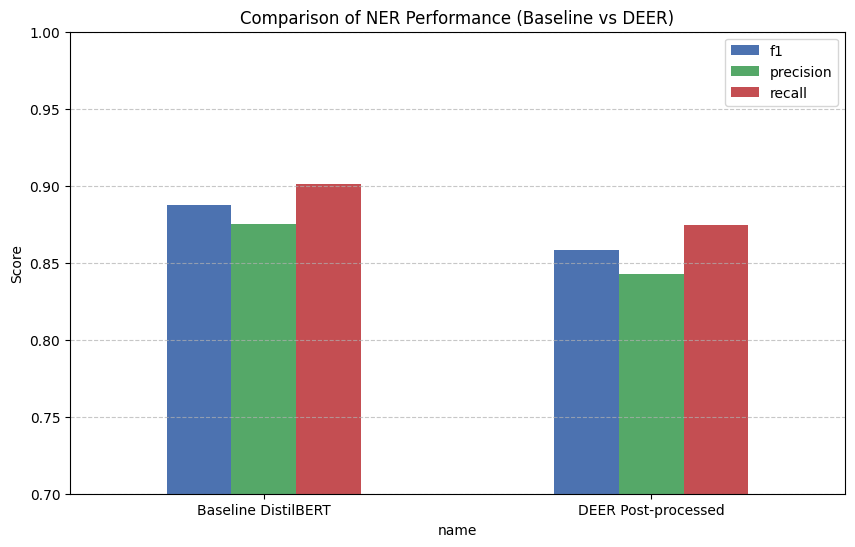

In [ ]:
class Evaluator:
    def __init__(self):
        self.y_true, self.y_pred_base, self.y_pred_deer = [], [], []

    def add_example(self, true_labels, base_pred, deer_pred):
        self.y_true.append(true_labels)
        self.y_pred_base.append(base_pred)
        self.y_pred_deer.append(deer_pred)

    def compute_metrics(self, predictions, name):
        return {
            "f1": f1_score(self.y_true, predictions),
            "precision": precision_score(self.y_true, predictions),
            "recall": recall_score(self.y_true, predictions),
            "name": name
        }

    def plot_comparison(self):
        base_metrics = self.compute_metrics(self.y_pred_base, "Baseline DistilBERT")
        deer_metrics = self.compute_metrics(self.y_pred_deer, "DEER Post-processed")

        print(f"=== {base_metrics['name']} ===")
        print(f"F1: {base_metrics['f1']:.4f} | Precision: {base_metrics['precision']:.4f} | Recall: {base_metrics['recall']:.4f}")

        print(f"\\n=== {deer_metrics['name']} ===")
        print(f"F1: {deer_metrics['f1']:.4f} | Precision: {deer_metrics['precision']:.4f} | Recall: {deer_metrics['recall']:.4f}")


        metrics_df = pd.DataFrame([base_metrics, deer_metrics]).set_index("name")
        metrics_df.plot(kind='bar', figsize=(10, 6), color=['#4C72B0', '#55A868', '#C44E52'])
        plt.title('Comparison of NER Performance (Baseline vs DEER)')
        plt.ylabel('Score')
        plt.ylim(0.7, 1.0)
        plt.xticks(rotation=0)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()


print("1. Loading standard conll2003 dataset...")
dataset = load_dataset("eriktks/conll2003", trust_remote_code=True)

print("\n2. Extracting Label-Guidance Statistics from Train set...")
guidance = LabelGuidanceStatistics(dataset['train'], len(dataset['train']))

print("\n3. Initializing Models...")
model = BaselineNERModel(config.model_name, config.device)
deer_processor = DEERInspiredPostProcessor(guidance.get_stats_dict())
evaluator = Evaluator()

print("\n4. Running Inference and Evaluation on Test set...")
test_data = dataset['test']

eval_limit = min(len(test_data), 2000)

for idx in range(eval_limit):
    example = test_data[idx]
    tokens = example["tokens"]
    gold_labels = [ID2LABEL[t] for t in example["ner_tags"]]

    base_preds = model.predict(tokens)
    deer_preds = deer_processor.process(tokens, base_preds)

    evaluator.add_example(gold_labels, base_preds, deer_preds)

    if (idx + 1) % 500 == 0:
        print(f"Processed {idx + 1}/{eval_limit} examples")

print("\\n5. Final Results Visualization:")
evaluator.plot_comparison()

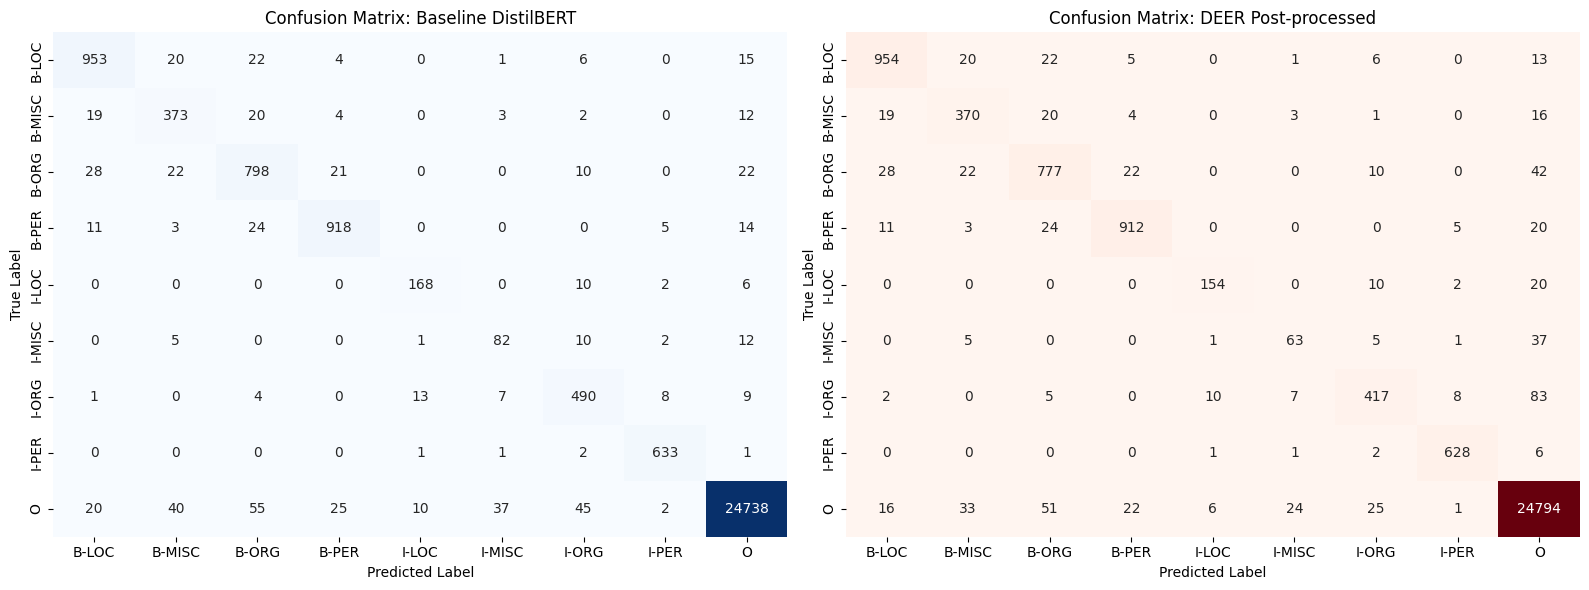

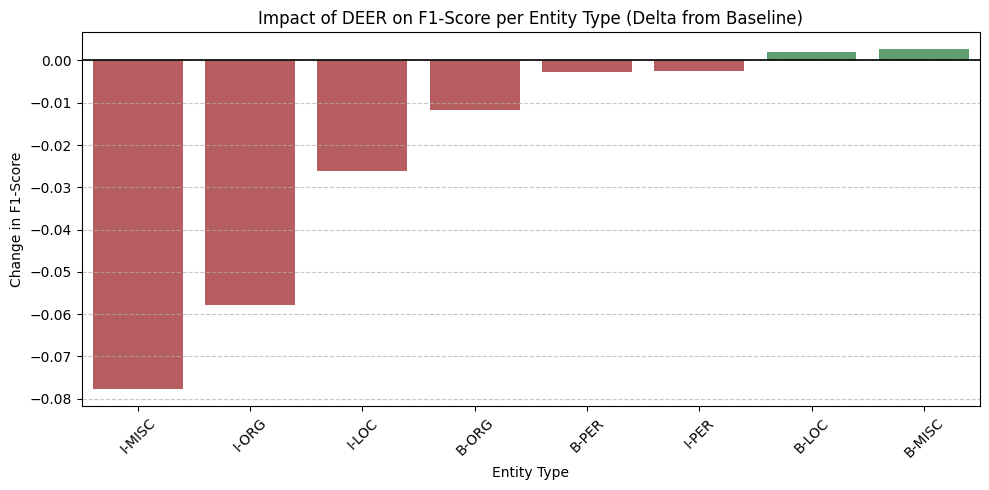

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

def plot_advanced_analytics(evaluator):
    # 1. Сплющиваем списки (из list of lists в плоский list)
    y_true_flat = [label for seq in evaluator.y_true for label in seq]
    y_base_flat = [label for seq in evaluator.y_pred_base for label in seq]
    y_deer_flat = [label for seq in evaluator.y_pred_deer for label in seq]


    labels = sorted(list(set(y_true_flat)))
    labels_no_o = [l for l in labels if l != 'O']


    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    cm_base = confusion_matrix(y_true_flat, y_base_flat, labels=labels)
    cm_deer = confusion_matrix(y_true_flat, y_deer_flat, labels=labels)

    sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=axes[0], cbar=False)
    axes[0].set_title('Confusion Matrix: Baseline DistilBERT')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    sns.heatmap(cm_deer, annot=True, fmt='d', cmap='Reds',
                xticklabels=labels, yticklabels=labels, ax=axes[1], cbar=False)
    axes[1].set_title('Confusion Matrix: DEER Post-processed')
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.show()

    report_base = classification_report(y_true_flat, y_base_flat, labels=labels_no_o, output_dict=True)
    report_deer = classification_report(y_true_flat, y_deer_flat, labels=labels_no_o, output_dict=True)

    f1_deltas = {}
    for label in labels_no_o:
        f1_base = report_base[label]['f1-score']
        f1_deer = report_deer[label]['f1-score']
        f1_deltas[label] = f1_deer - f1_base # Отрицательное значение = DEER ухудшил

    delta_df = pd.DataFrame(list(f1_deltas.items()), columns=['Entity', 'F1 Delta'])
    delta_df = delta_df.sort_values(by='F1 Delta')

    plt.figure(figsize=(10, 5))
    colors = ['#C44E52' if x < 0 else '#55A868' for x in delta_df['F1 Delta']]
    sns.barplot(x='Entity', y='F1 Delta', data=delta_df, palette=colors)

    plt.title('Impact of DEER on F1-Score per Entity Type (Delta from Baseline)')
    plt.ylabel('Change in F1-Score')
    plt.xlabel('Entity Type')
    plt.axhline(0, color='black', linewidth=1.2)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_advanced_analytics(evaluator)

Применение жёстких статистических порогов (например, замена предсказания DistilBERT на наиболее частотный класс в датасете) приводит к деградации точности и полноты на сложных многозначных сущностях, таких как Washington (85% ORG vs 15% LOC). В отличие от оригинальной DEER (EMNLP-25), где используются LLM с контекстным учётом label guidance, перенос этой логики на BERT-подобные модели в виде «глобального словаря» с пороговыми правилами неизбежно ухудшает качество на датасетах вроде CoNLL-2003.